# CEE6501 — Coding Assignment, Week 5

**Assigned:** 02/13/2026 (Week 5)  
**Due:** 02/23/2026

**Canvas Submission Link:**  <https://gatech.instructure.com/courses/517856/assignments/2320760>

---

## Logistics

### 💻 Assignment Format

This is a **coding assignment**.

- Complete the assignment by **executing and completing all tasks in the notebook cells below**
- The notebook should be run and completed in **Google Colab**
- Your submission **must be a link to a functioning Google Colab notebook**

You may use any local tools (VS Code, JupyterLab, etc.) while working, but the **final submitted work must run correctly in Colab**.


### 📤 Submission Instructions

- Submit **one link** to your Google Colab notebook on Canvas
- Ensure that:
  - All cells run **top-to-bottom without errors**
  - All required outputs are visible
  - The notebook reflects your final answers

### ✅ Checklist Before Submitting

- [ ] All notebook cells completed
- [ ] Code runs without errors from a fresh runtime
- [ ] Outputs and plots are clearly visible
- [ ] Colab link opens and runs correctly
- [ ] Correct notebook submitted on Canvas

### 🤝 Collaboration / AI tools
You may discuss concepts with classmates and you may use AI tools to help you learn,
but **your submitted code must be written by you and you must understand it**.
If you used outside help, add a short note in the final reflection cell.

---

## --- Google Colab environment setup ---

The cell below only needs to run when the notebook is opened in Google Colab.

This code will not affect code execution locally in VS-code + conda environment.

Google Colab starts each session with its own **preloaded versions** of common Python (currently 3.12.12) and Python packages (NumPy, SciPy, etc.).  
If we install different package versions once loaded, Python cannot switch to them while it is already running.

### What will happen
When you run the setup cell below in Google Colab:

1. The required package versions are installed
2. The runtime is **automatically restarted** so the new versions can be loaded  
3. You may see the message **“Your session crashed for an unknown reason.”**  
   → This is expected and normal

After the restart, rerun the notebook and check the **version check cell** to confirm package versions are correct.

### Runtime menu notes
- **Runtime → Restart session**  
  Restarts Python but keeps installed packages and saved files

- **Runtime → Disconnect and delete runtime**  
  Resets Colab completely to its default environment (packages will need to be reinstalled)

In [595]:
# ============================================================
# Google Colab environment setup (pinned versions)
# ============================================================

import sys
import os
import subprocess

if "google.colab" in sys.modules:
    print("Running in Google Colab")
    print("Python version:", sys.version.split()[0])

    # ---- Required package versions --------------------------
    requirements = {
        "numpy": "2.4.0",
        "scipy": "1.16.3",
        "matplotlib": "3.10.8",
        "pandas": "2.3.3",
        "plotly": "6.5.2"
    }

    # ---- Check currently loaded versions --------------------
    restart_needed = False

    for pkg, required_version in requirements.items():
        try:
            module = __import__(pkg)
            installed_version = module.__version__
        except Exception:
            installed_version = None

        print(f"{pkg}: {installed_version} (required: {required_version})")

        if installed_version != required_version:
            restart_needed = True

    # ---- Install if needed ----------------------------------
    if restart_needed:
        print("\nInstalling pinned package versions...")

        pip_args = [
            f"{pkg}=={ver}" for pkg, ver in requirements.items()
        ]

        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", *pip_args]
        )

        print("Installation complete.")
        print("Restarting runtime to load correct packages...")

        # This will appear as a "crash" in Colab — expected behavior
        os.kill(os.getpid(), 9)

    else:
        print("\nAll required package versions already installed.")

else:
    print("Not running in Google Colab — setup skipped.")
    print("Python version:", sys.version.split()[0])

Not running in Google Colab — setup skipped.
Python version: 3.12.12


In [596]:
# --- Version check ---
import numpy
import scipy
import matplotlib
import pandas
import plotly

print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("matplotlib:", matplotlib.__version__)
print("pandas:", pandas.__version__)
print("plotly:", plotly.__version__)

numpy: 2.4.0
scipy: 1.16.3
matplotlib: 3.10.8
pandas: 2.3.3
plotly: 6.5.2


---
---

## Imports

Run this cell once before starting the assignment.

In [597]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.set_printoptions(precision=3, suppress=True)


---

## GIVEN CODE (Do not modify):

## Parsing & Helper Functions

In [598]:
def restrained_dofs_1based(nodes_restrained, node_dofs_1based):
    """Return sorted list of restrained DOFs (1-based) from node restraints."""
    dof_restrained = []

    for node, restraints in nodes_restrained.items():
        ux_dof, uy_dof = node_dofs_1based(node)
        if "ux" in restraints:
            dof_restrained.append(ux_dof)
        if "uy" in restraints:
            dof_restrained.append(uy_dof)

    return sorted(dof_restrained)

In [599]:
def loaded_dofs_1based(nodes_loaded, node_dofs_1based):
    """Return DOF→load mapping (1-based) from node loads."""
    dof_loaded = {}

    for node, (Fx, Fy) in nodes_loaded.items():
        ux_dof, uy_dof = node_dofs_1based(node)
        if Fx != 0.0:
            dof_loaded[ux_dof] = dof_loaded.get(ux_dof, 0.0) + Fx
        if Fy != 0.0:
            dof_loaded[uy_dof] = dof_loaded.get(uy_dof, 0.0) + Fy

    return dof_loaded


In [600]:
def displaced_dofs_1based(nodes_displaced, node_dofs_1based):
    """Return DOF→displaced mapping (1-based) from node loads."""
    dof_displaced = {}

    for node, (Fx, Fy) in nodes_displaced.items():
        ux_dof, uy_dof = node_dofs_1based(node)
        if Fx != 0.0:
            dof_displaced[ux_dof] = dof_displaced.get(ux_dof, 0.0) + Fx
        if Fy != 0.0:
            dof_displaced[uy_dof] = dof_displaced.get(uy_dof, 0.0) + Fy

    return dof_displaced

In [601]:
def node_dofs_1based(node_id):
    """Return engineering DOF numbers (1-based): [ux_dof, uy_dof]."""
    return [2 * node_id - 1, 2 * node_id]

## Element Level

In [602]:
def element_csL(xy_i, xy_j):
    xy_i = np.asarray(xy_i, dtype=float)
    xy_j = np.asarray(xy_j, dtype=float)

    dx = xy_j[0] - xy_i[0]
    dy = xy_j[1] - xy_i[1]
    L = float(np.hypot(dx, dy))

    c = dx / L
    s = dy / L
    return float(c), float(s), float(L)

In [603]:
def build_elements_csl(elements, nodes):
    """Return dict mapping element_id -> (c, s, L)."""
    elements_csl = {}

    for e_id, (i, j, E_e, A_e) in elements.items():
        c, s, L = element_csL(nodes[i], nodes[j])
        elements_csl[e_id] = (c, s, L)

    return elements_csl

## Global Stiffness and Force

In [604]:
def initialize_global_stiffness(nodes):
    """Return zero-initialized global stiffness matrix."""
    ndof_total = 2 * len(nodes)
    return np.zeros((ndof_total, ndof_total), dtype=float)

In [605]:
def truss_element_kg(E, A, c, s, L):
    """Return 4x4 global stiffness matrix for a 2D truss element."""
    factor = (E * A) / L

    c2 = c * c
    s2 = s * s
    cs = c * s

    kg = factor * np.array(
        [
            [ c2,  cs, -c2, -cs],
            [ cs,  s2, -cs, -s2],
            [-c2, -cs,  c2,  cs],
            [-cs, -s2,  cs,  s2],
        ],
        dtype=float,
    )
    return kg

In [606]:
def element_dof_map_1based(i_node, j_node):
    """Return the 4 global DOF indices (1-based) for element (i, j).

    Order matches the 4x4 element stiffness matrix:
    [u_ix, u_iy, u_jx, u_jy]
    """
    # Engineering DOF numbers (1-based)
    dofs_i_1 = [2 * i_node - 1, 2 * i_node]
    dofs_j_1 = [2 * j_node - 1, 2 * j_node]
    dofs_1based = dofs_i_1 + dofs_j_1
    return dofs_1based

In [607]:
def assemble_global_stiffness(elements, nodes, elements_csl, print_toggle):
    """Assemble and return the global stiffness matrix K (dense) for a 2D truss."""

    K = initialize_global_stiffness(nodes)

    for e_id, (i, j, E_e, A_e) in elements.items():
        c, s, L = elements_csl[e_id]
        ke = truss_element_kg(E_e, A_e, c, s, L)
        
        dof_map = element_dof_map_1based(i, j)

        # Scatter-add ke into K. Must be 0-based indexing, hence -1
        for a in range(4):
            A = dof_map[a] - 1
            for b in range(4):
                B = dof_map[b] - 1
                K[A, B] += ke[a, b]

        # Optional: show progress while learning/debugging
        if print_toggle:
            print_matrix_scaled(ke)
            print(f"Assembled element {e_id}: nodes ({i},{j}) -> DOFs {dof_map}")
            print_matrix_scaled(K)
            print("-" * 70)

    return K

In [608]:
def assemble_global_force_vector(nodes, dof_loaded_1based):
    """Return global force vector assembled from 1-based DOF loads."""
    ndof_total = 2 * len(nodes)
    f_global = np.zeros(ndof_total, dtype=float)

    for dof_1based, value in dof_loaded_1based.items():
        f_global[dof_1based - 1] = value  # convert to 0-based index

    return f_global

In [609]:
def assemble_global_displacement_vector(nodes, dof_displaced_1based):
    """Return global force vector assembled from 1-based DOF loads."""
    ndof_total = 2 * len(nodes)
    u_global = np.zeros(ndof_total, dtype=float)

    # If nothing provided, just return zeros
    if not dof_displaced_1based:
        return u_global

    # Assemble prescribed displacements
    for dof_1based, value in dof_displaced_1based.items():
        u_global[dof_1based - 1] = value  # convert to 0-based index

    return u_global

## Partition

In [610]:
def partition_system(K, f, u, dof_restrained_1based):
    ndof = K.shape[0]

    # Convert restrained DOFs to 0-based
    restrained_dofs = sorted(d - 1 for d in dof_restrained_1based)

    # # Convert restrained DOFs to 0-based
    # displaced_dofs = sorted(d - 1 for d in dof_displaced_1based)

    # Free DOFs
    free_dofs = [i for i in range(ndof) if i not in restrained_dofs]

    # Partition stiffness matrix
    K_ff = K[np.ix_(free_dofs, free_dofs)]
    K_fr = K[np.ix_(free_dofs, restrained_dofs)]
    K_rf = K[np.ix_(restrained_dofs, free_dofs)]
    K_rr = K[np.ix_(restrained_dofs, restrained_dofs)]

    # Partition force vector
    f_f = f[free_dofs]
    f_r = f[restrained_dofs]

    # Partition displaced vector
    # u_f = u[free_dofs]
    u_r = u[restrained_dofs]

    return K_ff, K_fr, K_rf, K_rr, f_f, f_r, u_r, free_dofs, restrained_dofs


## Solve Displacements

In [611]:
def solve_free_displacements(K_ff, K_fr, f_f, u_r=None):

    
    if u_r is None:
        print("I'm in solve disp here")
        print (u_r)
        u_r = np.zeros(K_fr.shape[1])
        

    rhs = f_f - K_fr @ u_r
    u_f = np.linalg.solve(K_ff, rhs)

    return u_f


## Solve Support Forces

In [612]:
def solve_support_forces(K_rf, K_rr, u_f, u_r=None):
    if u_r is None:
        print("I'm in solve forces here")
        print (u_r)
        u_r = np.zeros(K_rr.shape[0])

    F_r = K_rf @ u_f + K_rr @ u_r
    return F_r


## Backward Pass

In [613]:
def assemble_global_displacements(u_f, free_dofs, restrained_dofs, u_r=None):
    """
    Assemble the full global displacement vector u from partitioned results.
    """
    ndof_total = len(free_dofs) + len(restrained_dofs)
    u_global = np.zeros(ndof_total)

    
    if u_r is None:
        print (u_r)
        print("im in assemble global disp")
        u_r = np.zeros(len(restrained_dofs))

    u_global[free_dofs] = u_f
    u_global[restrained_dofs] = u_r

    return u_global


In [614]:
def assemble_global_forces(f_f, F_r, free_dofs, restrained_dofs):
    """
    Assemble the full global force vector f from applied loads and reactions.
    """
    ndof_total = len(free_dofs) + len(restrained_dofs)
    f_global = np.zeros(ndof_total)

    f_global[free_dofs] = f_f
    f_global[restrained_dofs] = F_r

    return f_global


In [615]:
def extract_element_displacements(u_global, i_node, j_node):
    """
    Extract the 4x1 element global displacement vector u_e.
    Order: [u_ix, u_iy, u_jx, u_jy]
    """
    dofs_1based = [2 * i_node - 1, 2 * i_node,
                   2 * j_node - 1, 2 * j_node]
    idx = [d - 1 for d in dofs_1based]  # convert to 0-based
    return u_global[idx]

In [616]:
def truss_transformation_matrix(c, s):
    return np.array(
        [
            [ c,  s,  0,  0],
            [-s,  c,  0,  0],
            [ 0,  0,  c,  s],
            [ 0,  0, -s,  c],
        ],
        dtype=float,
    )

def compute_local_displacements(c, s, u_e):
    T = truss_transformation_matrix(c, s)
    return T @ u_e



In [617]:
def truss_local_stiffness(E, A, L):
    return (E * A / L) * np.array(
        [
            [ 1, 0, -1, 0],
            [ 0, 0,  0, 0],
            [-1, 0,  1, 0],
            [ 0, 0,  0, 0],
        ],
        dtype=float,
    )

In [618]:
def compute_local_end_forces(E, A, L, u_local):
    k_local = truss_local_stiffness(E, A, L)
    return k_local @ u_local

In [619]:
def compute_axial_force_and_stress(E, A, L, u_local):
    # axial displacements are the local DOFs along the member axis
    u_i_axial = u_local[0]
    u_j_axial = u_local[2]

    N = (E * A / L) * (u_j_axial - u_i_axial)
    sigma = N / A
    return N, sigma

In [620]:
def local_to_global_forces(c, s, f_local):
    T = truss_transformation_matrix(c, s)
    return T.T @ f_local

## Post-Processing & Output

In [621]:
def plot_truss_deformation(nodes, elements, u_global, scale=1.0):
    """
    Plot original (black) and deformed (red) truss geometry.
    """
    plt.figure()

    for e_id, (i, j, *_ ) in elements.items():
        xi, yi = nodes[i]
        xj, yj = nodes[j]

        ui = u_global[2*(i-1):2*(i-1)+2]
        uj = u_global[2*(j-1):2*(j-1)+2]

        # original
        plt.plot([xi, xj], [yi, yj], "k-", lw=2)

        # deformed
        plt.plot(
            [xi + scale*ui[0], xj + scale*uj[0]],
            [yi + scale*ui[1], yj + scale*uj[1]],
            "r-", lw=2
        )

    plt.axis("equal")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Original (black) and deformed (red), scale={scale}")
    plt.show()


In [622]:
def recover_element_results(elements, elements_csl, u_global):
    results = {}

    for e_id, (i, j, E_e, A_e) in elements.items():
        c, s, L = elements_csl[e_id]

        u_e = extract_element_displacements(u_global, i, j)
        u_local = compute_local_displacements(c, s, u_e)
        f_local = compute_local_end_forces(E_e, A_e, L, u_local)
        N, sigma = compute_axial_force_and_stress(E_e, A_e, L, u_local)

        results[e_id] = {
            "u_e": u_e,
            "u_local": u_local,
            "f_local": f_local,
            "N": N,          # kN
            "sigma": sigma,  # GPa
        }

    return results

In [623]:
def build_element_results_dataframe(elements, elements_csl, results):
    """Return pandas DataFrame of element-level results."""
    rows = []

    for e_id in sorted(elements.keys()):
        i, j, _, _ = elements[e_id]
        _, _, L = elements_csl[e_id]
        r = results[e_id]

        row = {
            "ele": e_id,
            "i": i,
            "j": j,
            "L (mm)": round(L, 1),
            "N (kN)": round(r["N"], 1),
            "sigma (MPa)": round(r["sigma"] * 1000, 1),
        }

        # global displacements u_e
        row.update({f"u_{k+1} (mm)": round(r["u_e"][k], 1) for k in range(4)})
        # local displacements u'
        row.update({f"u_{k+1}' (mm)": round(r["u_local"][k], 1) for k in range(4)})
        # local end forces f'
        row.update({f"f_{k+1}' (kN)": round(r["f_local"][k], 1) for k in range(4)})

        rows.append(row)

    return pd.DataFrame(rows)


In [624]:
def display_compact(df):
    return (
        df.style
        .format({
            col: "{:.1f}"
            for col in df.columns
            if any(key in col for key in ["(mm)", "(kN)", "(MPa)", "L"])
        })
        .set_properties(**{
            "font-size": "9pt",
            "padding": "2px",
            "white-space": "nowrap",
        })
        .set_table_styles([
            {"selector": "th", "props": [("font-size", "9pt")]},
        ])
    )


In [625]:
def print_matrix_scaled(K, scale=1, decimals=2, col_width=7):
    """
    Print K/scale row-by-row, compact, with DOF labels.
    """
    fmt = f"{{:{col_width}.{decimals}f}}"
    print(f"K = {scale:.0e} ×")
    for i, row in enumerate(K, start=1):
        row_scaled = row / scale
        row_str = " ".join(fmt.format(val) for val in row_scaled)
        print(f"{i:2d} | {row_str}")

---
---

## Question 1 (20 Points)

Using the functions defined above. Verify that you are getting the same answers as the statically determinate truss solved in the written assignment.

### Q1.1. Problem Setup
Define all model inputs (nodes, elements, supports, loads) using the same data structures and conventions as we did in lecture.

Replace the data in the cells below that currently define the in-class problem.

Present:
- Node coordinates
- Element connectivity and properties
- Applied loads and boundary conditions

In [626]:
# Node coordinates (global)
# Format: node_id : (x, y)

nodes = {
    1: (6000.0, 8000.0),
    2: (0.0, 0.0),
    3: (8000.0, 0.0),
    4: (12000.0, 0.0)
}

# Quick check: DOFs for each node
{nid: node_dofs_1based(nid) for nid in nodes}


{1: [1, 2], 2: [3, 4], 3: [5, 6], 4: [7, 8]}

In [627]:
# Material and section properties
E = 200.0   # GPa
A1 = 4000.0    # mm^2
A2 = 3000.0    # mm^2

# Element connectivity and properties
# Format: element_id : (start_node, end_node, E, A)
elements = {
    1: (2, 1, E, A1),
    2: (3, 1, E, A2),
    3: (4, 1, E, A1),
}

elements_csl = build_elements_csl(elements, nodes)

print (elements)
print(elements_csl)

{1: (2, 1, 200.0, 4000.0), 2: (3, 1, 200.0, 3000.0), 3: (4, 1, 200.0, 4000.0)}
{1: (0.6, 0.8, 10000.0), 2: (-0.24253562503633297, 0.9701425001453319, 8246.211251235321), 3: (-0.6, 0.8, 10000.0)}


In [636]:
# Node-level description of restraints
# Values indicate which DOFs are fixed at each node
nodes_restrained = {
    2: ["ux", "uy"],   # pin
    3: ["ux", "uy"],   # pin
    4: ["ux", "uy"]          # x-roller
}

# Node-level applied loads (Fx, Fy)
nodes_loaded = {
    # 1: (0.0, -400.0),
}

# Node-level applied loads (u_x, u_y)
nodes_displaced = {
    4: (0.0, -10),
}

print(nodes_restrained)
print(nodes_loaded)
print(nodes_displaced)

{2: ['ux', 'uy'], 3: ['ux', 'uy'], 4: ['ux', 'uy']}
{}
{4: (0.0, -10)}


In [637]:
dof_restrained_1based = restrained_dofs_1based(nodes_restrained, node_dofs_1based)
dof_loaded_1based = loaded_dofs_1based(nodes_loaded, node_dofs_1based)
dof_displaced_1based = displaced_dofs_1based(nodes_displaced, node_dofs_1based)

print(dof_restrained_1based)
print(dof_loaded_1based)
print(dof_displaced_1based)


[3, 4, 5, 6, 7, 8]
{}
{8: -10.0}


---

### Q1.2 Analysis
Solve the truss using the planar truss functions developed in lecture.

Report key numerical results, such as:
- Support reactions
- Member axial forces
- Maximum nodal displacements
- Present summary tables
- Plot displaced shape at a reasonable scale

In [639]:
print_toggle = 0
K_global = assemble_global_stiffness(elements, nodes, elements_csl, print_toggle)
f_global = assemble_global_force_vector(nodes, dof_loaded_1based)
u_global = assemble_global_displacement_vector(nodes, dof_displaced_1based)

print(f_global)
print("u_global", u_global)

(
    K_ff,
    K_fr,
    K_rf,
    K_rr,
    f_f,
    f_r,
    u_r,
    free_dofs,
    restrained_dofs,
) = partition_system(K_global, f_global, u_global, dof_restrained_1based)

u_f = solve_free_displacements(K_ff, K_fr, f_f, u_r=u_r)
F_r = solve_support_forces(K_rf, K_rr, u_f, u_r=u_r)

u_global = assemble_global_displacements(u_f, free_dofs, restrained_dofs, u_r=u_r)
f_global_complete = assemble_global_forces(f_f, F_r, free_dofs, restrained_dofs)

print(u_f)
print(F_r)
print(u_global)



[0. 0. 0. 0. 0. 0. 0. 0.]
u_global [  0.   0.   0.   0.   0.   0.   0. -10.]
[ 5.53  -2.442]
[ -65.479  -87.306  -65.479  261.917  130.958 -174.611]
[  5.53   -2.442   0.      0.      0.      0.      0.    -10.   ]


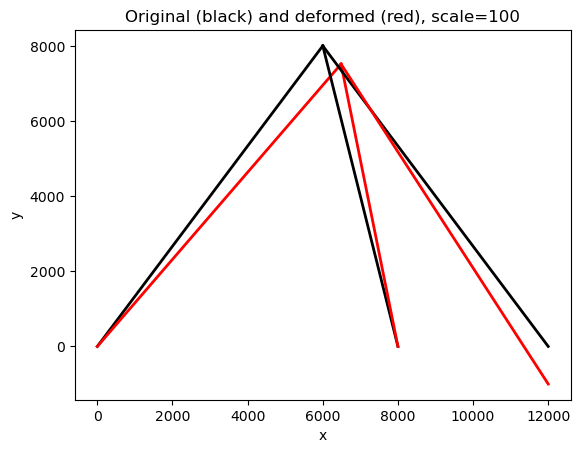

In [631]:
plot_truss_deformation(nodes, elements, u_global, scale=100)

In [640]:
results = recover_element_results(elements, elements_csl, u_global)
df_members = build_element_results_dataframe(elements, elements_csl, results)
display_compact(df_members)

,ele,i,j,L (mm),N (kN),sigma (MPa),u_1 (mm),u_2 (mm),u_3 (mm),u_4 (mm),u_1' (mm),u_2' (mm),u_3' (mm),u_4' (mm),f_1' (kN),f_2' (kN),f_3' (kN),f_4' (kN)
0,1,2,1,10000.0,109.1,27.3,0.0,0.0,5.5,-2.4,0.0,0.0,1.4,-5.9,-109.1,0.0,109.1,0.0
1,2,3,1,8246.2,-270.0,-90.0,0.0,0.0,5.5,-2.4,0.0,0.0,-3.7,-4.8,270.0,0.0,-270.0,0.0
2,3,4,1,10000.0,218.3,54.6,0.0,-10.0,5.5,-2.4,-8.0,6.0,-5.3,-3.0,-218.3,0.0,218.3,0.0


In [633]:
# Choose one element to sanity-check
e_test = 1

# --- Geometry + properties ---
i, j, E, A = elements[e_test]
c, s, L = elements_csl.get(e_test, element_csL(nodes[i], nodes[j]))

print(f"Element {e_test}: nodes ({i}, {j})")
print(f"c = {c:.6f}, s = {s:.6f}, L = {L:.3f} mm")

# --- Displacements ---
u_e = extract_element_displacements(u_global, i, j)
print(f"u_e (ele {e_test} global displacements) = {u_e}")

u_local = compute_local_displacements(c, s, u_e)
print(f"u_local (ele {e_test} local displacements) = {u_local}")

# --- Forces / stress ---
f_local = compute_local_end_forces(E, A, L, u_local)
print(f"f_local (ele {e_test} local end forces) = {f_local}")

N, sigma = compute_axial_force_and_stress(E, A, L, u_local)
print(f"Axial force  N = {N:.3f} kN")
print(f"Axial stress σ = {sigma:.6f} GPa  ({sigma*1000:.2f} MPa)")

f_global_e = local_to_global_forces(c, s, f_local)
print(f"f_global_e (ele {e_test} end forces in global coords) = {f_global_e}")


Element 1: nodes (2, 1)
c = 0.600000, s = 0.800000, L = 10000.000 mm
u_e (ele 1 global displacements) = [ 0.     0.     4.864 -4.85 ]
u_local (ele 1 local displacements) = [ 0.     0.    -0.962 -6.801]
f_local (ele 1 local end forces) = [ 76.923   0.    -76.923   0.   ]
Axial force  N = -76.923 kN
Axial stress σ = -0.019231 GPa  (-19.23 MPa)
f_global_e (ele 1 end forces in global coords) = [ 46.154  61.539 -46.154 -61.539]


### YOUR ANSWER FOR Q1.2 IN THIS CELL:

Use as many cells as you need

---

### Q1.3 Discussion

Compare the support reactions and member foces obtained from your code with those calculated by hand. State whether they agree, and briefly summarize your findings in the final cell using **Markdown** and **LaTeX** as appropriate.

### YOUR ANSWER FOR Q1.3 IN THIS CELL:

Use as many cells as you need

---
---

---

## Reflection (Required)

In 3–6 sentences:

- What part felt easiest? Describe in speciics
- What part felt hardest? Describe in speciics
- One bug you encountered and how you fixed it.
- One thing you still don’t understand.
- If you used collaboration or AI tools, briefly describe how.


### YOUR RESPONSE HERE